In [34]:
import pandas as pd
import numpy as np
data = pd.read_csv('/Users/lorenzoallegrini/Python_ML/Machine_Learning/datasets/digit-recognizer/train.csv')
data = np.array(data)

m, n = data.shape
data_dev = data[0:1000].T
Y_dev = data_dev[0]
X_dev = data_dev[1: n] / 255

data_train = data[1000:m].T
Y_train = data_train[0]
X_train = data_train[1:n] / 255

In [35]:
def init_params():
    hidden_size = 64
    W1 = np.random.randn(hidden_size, 784) * np.sqrt(2 / 784)
    b1 = np.zeros((hidden_size,1))
    W2 = np.random.randn(hidden_size, hidden_size) * np.sqrt(2 / hidden_size)
    b2 = np.zeros((hidden_size,1))
    W3 = np.random.randn(10, hidden_size) * np.sqrt(2 / hidden_size)
    b3 = np.zeros((10,1))
    return W1, b1, W2, b2, W3, b3

def ReLU(Z):
    return np.maximum(0,Z)

def softmax(Z):
    Z_stable = Z - np.max(Z, axis=0, keepdims=True)
    A = np.exp(Z_stable) / np.sum(np.exp(Z_stable), axis=0, keepdims=True)
    return A

def forward_prop(W1, b1, W2, b2, W3, b3, X):
    Z1 = W1.dot(X) + b1
    A1 = ReLU(Z1)
    Z2 = W2.dot(A1) + b2
    A2 = ReLU(Z2)
    Z3 = W3.dot(A2) + b3
    A3 = softmax(Z3)
    return Z1, A1, Z2, A2, Z3, A3

def one_hot(Y):
    Y = Y.astype(int).flatten()
    one_hot_Y = np.zeros((Y.size, Y.max() + 1))
    one_hot_Y[np.arange(Y.size), Y] = 1
    one_hot_Y = one_hot_Y.T
    return one_hot_Y

def ReLU_deriv(Z):
    return Z > 0

def back_prop(Z1, A1, Z2, A2, W1, W2, Z3, A3, W3, X, Y):
    m = X.shape[1]
    one_hot_Y = one_hot(Y)
    dZ3 = A3 - one_hot_Y
    dW3 = 1 / m * dZ3.dot(A2.T)
    db3 = 1 / m * np.sum(dZ3, axis = 1, keepdims = True)
    dZ2 = W3.T.dot(dZ3) * ReLU_deriv(Z2)
    dW2 = 1 / m * dZ2.dot(A1.T)
    db2 = 1 / m * np.sum(dZ2, axis = 1, keepdims = True)
    dZ1 = W2.T.dot(dZ2) * ReLU_deriv(Z1)
    dW1 = 1 / m * dZ1.dot(X.T)
    db1 = 1 / m * np.sum(dZ1, axis = 1, keepdims = True)
    return dW1, db1, dW2, db2, dW3, db3

def update_params(W1, b1, W2, b2, W3, b3, dW1, db1, dW2, db2, dW3, db3, alpha):
    W1 = W1 - alpha * dW1
    b1 = b1 - alpha * db1
    W2 = W2 - alpha * dW2 
    b2 = b2 - alpha * db2
    W3 = W3 - alpha * dW3
    b3 = b3 - alpha * db3
    return W1, b1, W2, b2, W3, b3

def get_predictions(A3):
    return np.argmax(A3, 0)

def get_accuracy(predictions, Y):
    print(predictions, Y)
    return np.sum(predictions == Y) / Y.size


def gradient_descent(X, Y, alpha, iterations, Continuing_training = False, save_path = None):

    if Continuing_training and save_path is not None:
            data = np.load(save_path)
            W1 = data['W1']
            b1 = data['b1']
            W2 = data['W2']
            b2 = data['b2']
            W3 = data['W3']
            b3 = data['b3'] 
            print('Resuming Training with saved weights')     
    else:
        W1, b1, W2, b2, W3, b3 = init_params()
        print('Training from scratch')
    for i in range(iterations):
        Z1, A1, Z2, A2, Z3, A3 = forward_prop(W1, b1, W2, b2, W3, b3, X)
        dW1, db1, dW2, db2, dW3, db3 = back_prop(Z1, A1, Z2, A2, W1, W2, Z3, A3, W3, X, Y)
        W1, b1, W2, b2, W3, b3 = update_params(W1, b1, W2, b2, W3, b3, dW1, db1, dW2, db2, dW3, db3, alpha)
        if i % 50 == 0:
            predictions = get_predictions(A3)
            print('Iteration: ', i)
            print(get_accuracy(predictions, Y))
    if save_path is not None:
        np.savez(save_path, W1=W1, b1=b1, W2=W2, b2=b2, W3=W3, b3=b3)
        print(f'Parameters saved to {save_path}')
    
    return W1, b1, W2, b2, W3, b3


In [36]:
W1, b1, W2, b2, W3, b3 = gradient_descent(X_train, Y_train, 0.1, 50, Continuing_training = True, save_path = 'mnist_params.npz')

Resuming Training with saved weights
Iteration:  0
[1 5 1 ... 7 6 9] [1 5 1 ... 7 6 9]
0.987390243902439
Parameters saved to mnist_params.npz


Prediction:  [1]
Label:  1


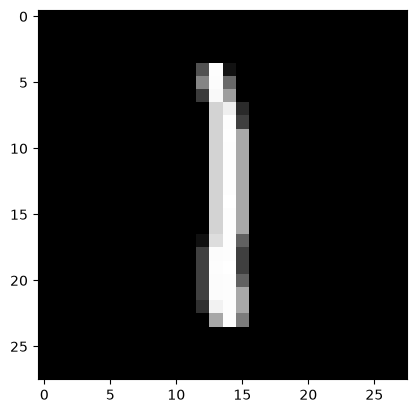

Prediction:  [5]
Label:  5


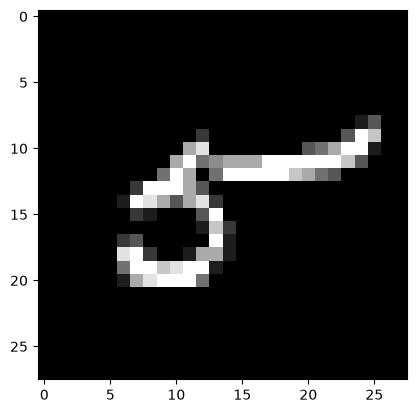

Prediction:  [1]
Label:  1


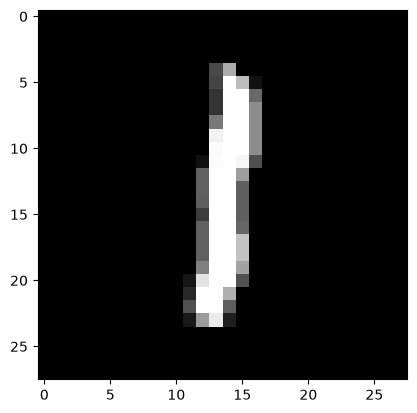

Prediction:  [7]
Label:  7


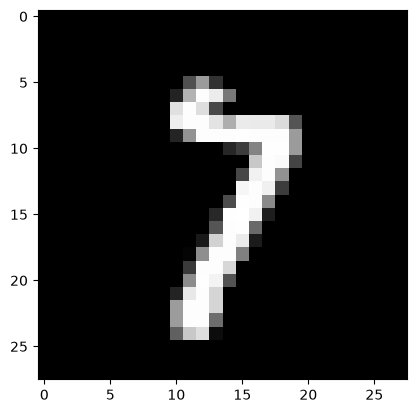

Prediction:  [4]
Label:  4


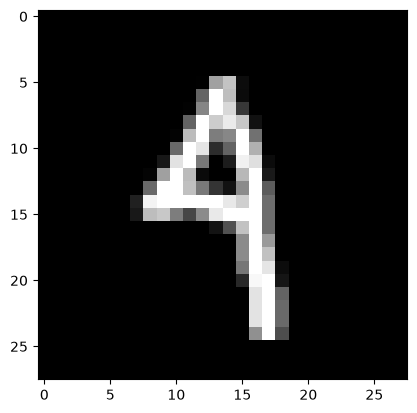

Prediction:  [8]
Label:  8


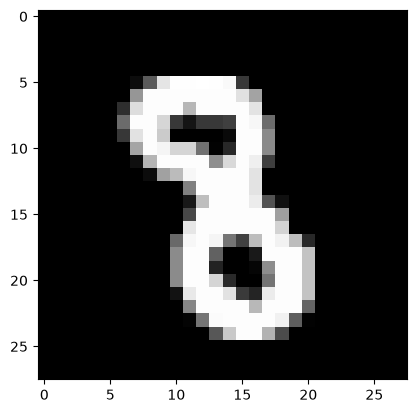

Prediction:  [9]
Label:  9


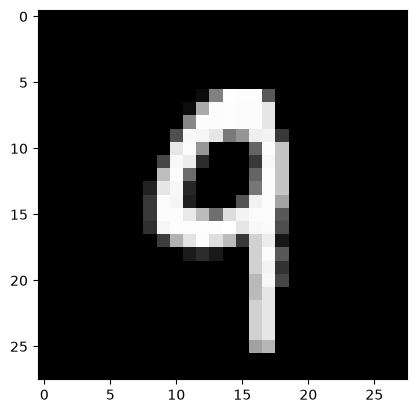

Prediction:  [5]
Label:  5


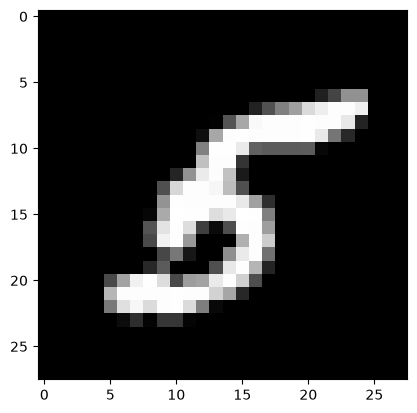

Prediction:  [7]
Label:  7


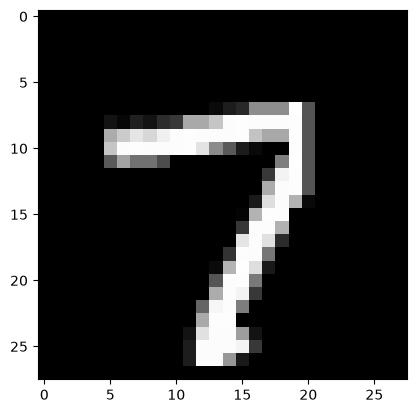

Prediction:  [4]
Label:  4


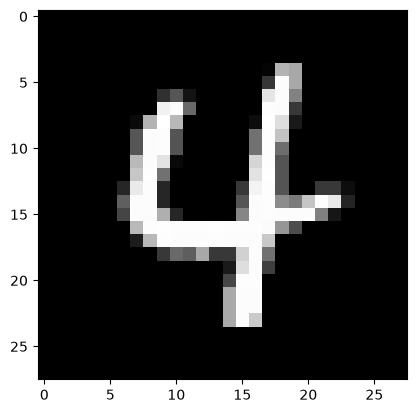

Prediction:  [7]
Label:  7


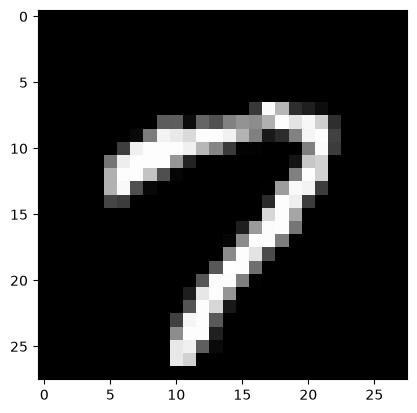

Prediction:  [2]
Label:  2


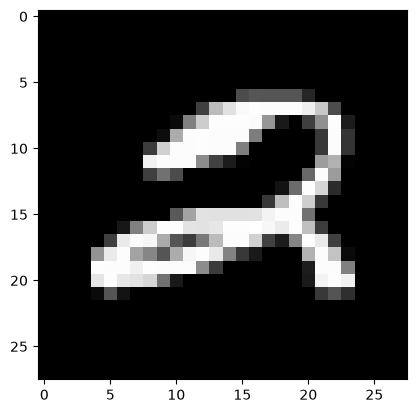

Prediction:  [2]
Label:  2


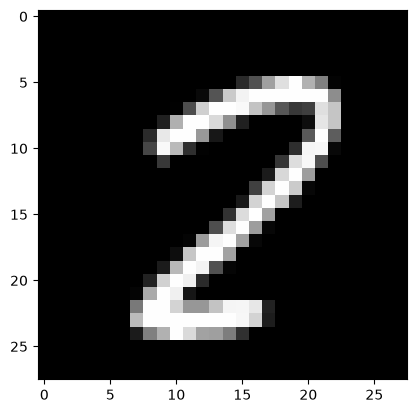

Prediction:  [1]
Label:  1


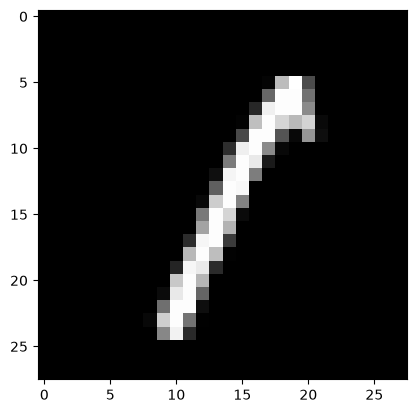

Prediction:  [4]
Label:  4


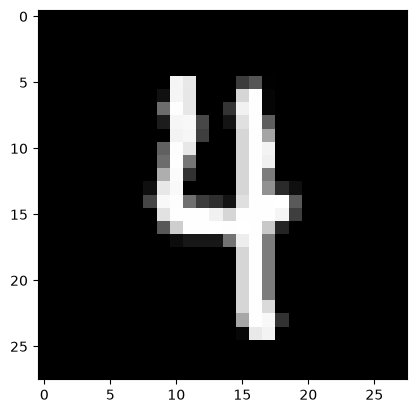

Prediction:  [8]
Label:  8


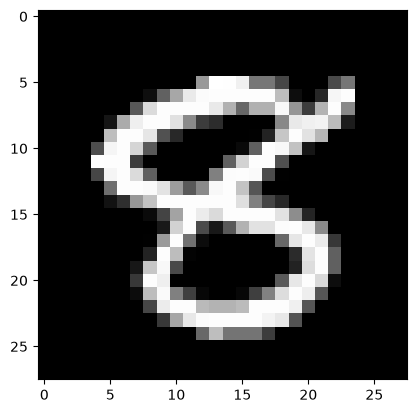

Prediction:  [8]
Label:  8


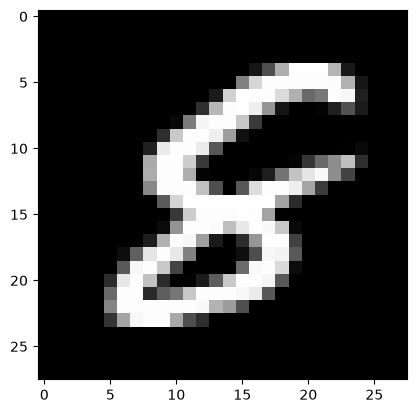

Prediction:  [6]
Label:  6


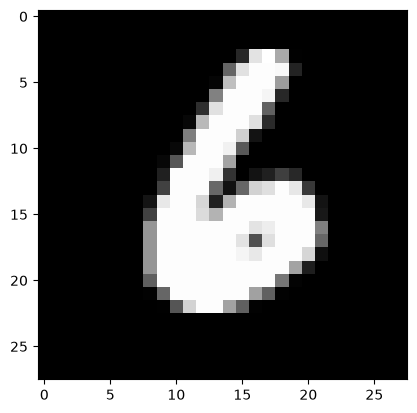

Prediction:  [2]
Label:  2


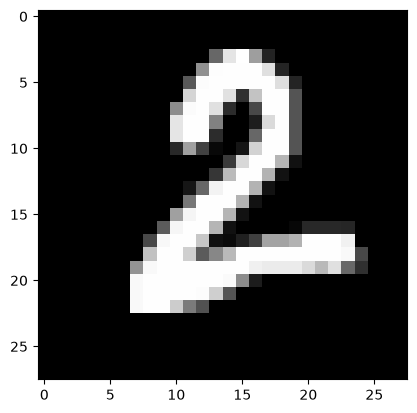

Prediction:  [2]
Label:  2


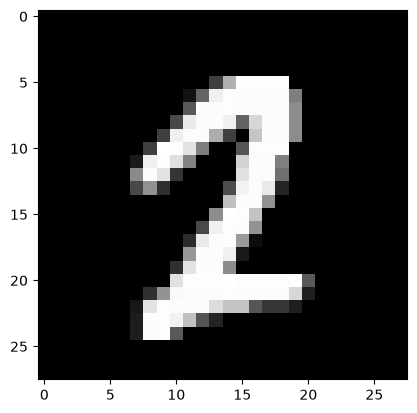

Prediction:  [2]
Label:  2


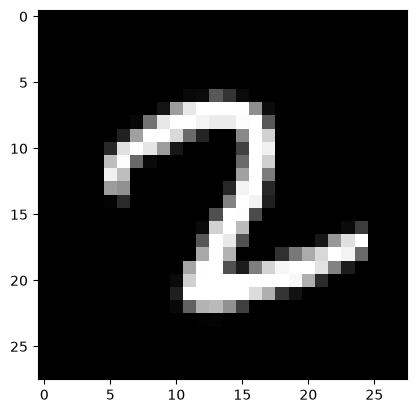

Prediction:  [6]
Label:  6


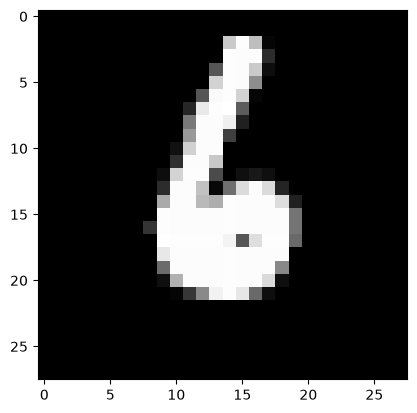

Prediction:  [7]
Label:  7


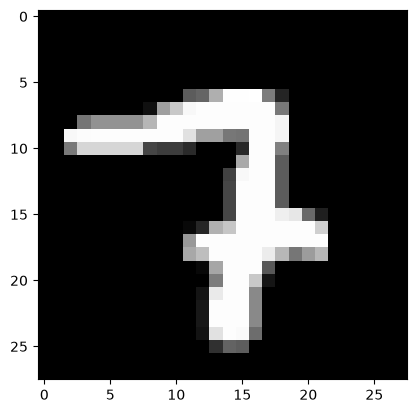

Prediction:  [8]
Label:  8


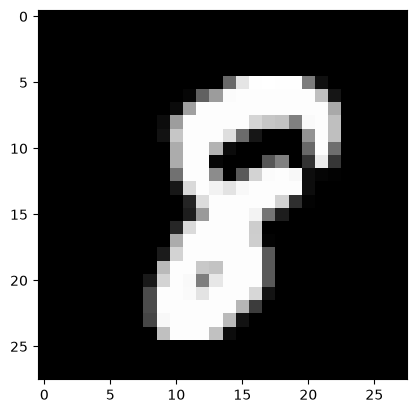

Prediction:  [1]
Label:  1


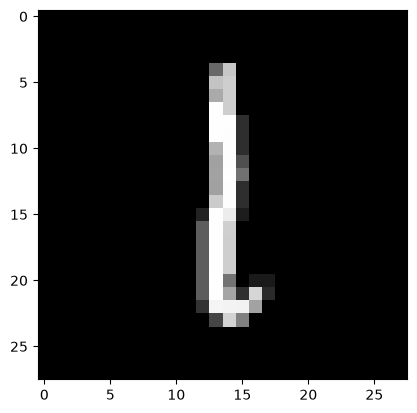

Prediction:  [8]
Label:  8


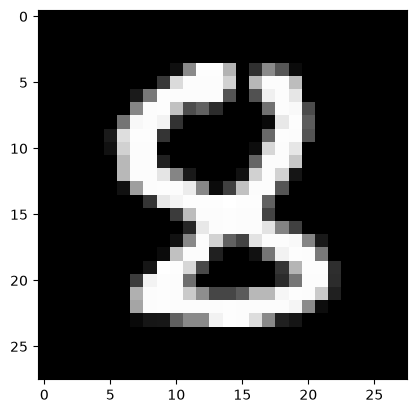

Prediction:  [8]
Label:  8


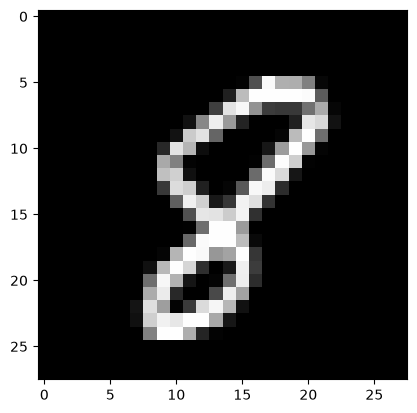

Prediction:  [1]
Label:  1


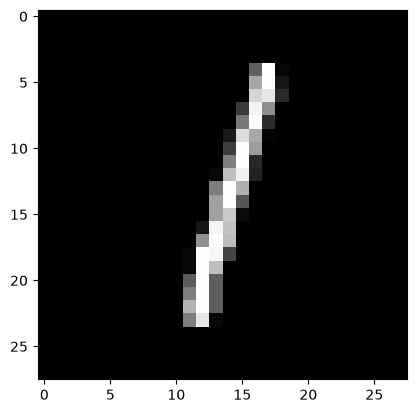

Prediction:  [9]
Label:  9


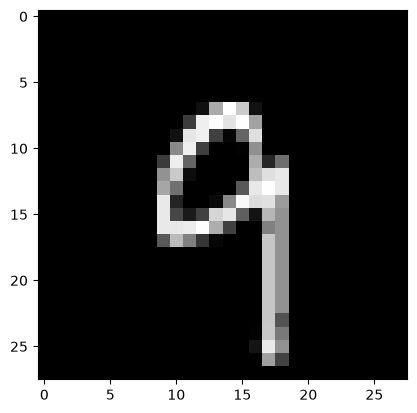

Prediction:  [0]
Label:  0


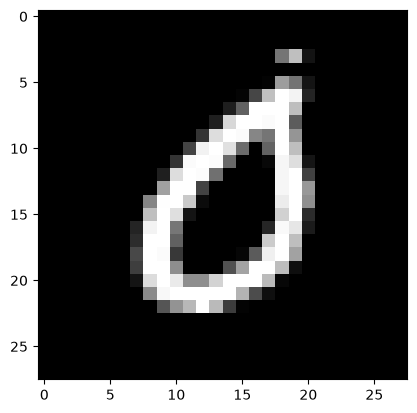

In [37]:
import matplotlib.pyplot as plt
def make_predictions(X, W1, b1, W2, b2, W3, b3):
    _, _, _, _, _, A3 = forward_prop(W1, b1, W2, b2, W3, b3, X)
    predictions = get_predictions(A3)
    return predictions

def test_prediction(index, W1, b1, W2, b2, W3, b3):
    current_image = X_train[:, index, None]
    prediction = make_predictions(X_train[:, index, None], W1, b1, W2, b2, W3, b3)
    label = Y_train[index]
    print("Prediction: ", prediction)
    print("Label: ", label)
    
    current_image = current_image.reshape((28, 28)) * 255
    plt.gray()
    plt.imshow(current_image, interpolation='nearest')
    plt.show()


for i in range(30): 
    test_prediction(i, W1, b1, W2, b2, W3, b3)


In [38]:
predictions_dev = make_predictions(X_dev, W1, b1, W2, b2, W3, b3)
accuracy_dev = get_accuracy(predictions_dev, Y_dev)
print(f"Validation accuracy: {accuracy_dev}")


[1 0 1 4 0 0 7 3 5 3 8 9 1 3 3 1 2 0 7 5 8 6 2 0 2 3 6 9 9 7 8 9 4 9 2 1 3
 1 1 4 9 1 4 9 2 6 3 7 7 4 7 5 1 9 0 2 2 3 9 1 1 1 5 0 6 3 4 8 1 0 3 9 6 2
 6 4 7 1 4 1 5 4 8 9 2 9 9 8 9 6 3 6 4 6 2 9 1 2 0 5 9 2 7 7 2 8 8 5 0 6 0
 0 2 9 0 4 7 7 1 5 7 9 4 6 1 3 7 6 5 0 4 8 7 6 1 8 7 3 7 3 1 0 3 4 5 4 0 5
 4 0 3 5 1 0 8 3 7 0 9 6 6 9 5 4 6 9 3 5 4 2 4 8 7 7 5 8 8 8 2 6 9 3 1 0 4
 1 5 9 0 6 2 4 3 0 6 0 0 8 3 2 0 0 6 0 0 4 7 2 7 1 9 9 3 9 8 4 6 6 5 3 8 1
 8 7 1 3 7 6 3 6 3 6 3 2 3 2 2 7 9 2 3 2 7 5 5 8 8 2 0 1 4 0 6 3 7 1 1 1 4
 7 0 2 9 2 0 5 6 0 8 9 6 2 0 0 7 2 0 4 2 0 9 1 6 9 3 0 0 2 0 6 8 4 0 7 2 1
 9 5 2 4 8 5 2 9 7 9 2 9 7 4 9 3 2 7 3 6 3 6 8 8 3 7 0 9 2 7 9 0 5 4 5 8 4
 3 3 1 7 8 9 7 6 2 1 7 0 5 6 5 2 9 5 4 6 2 2 2 9 0 7 7 2 2 6 3 4 2 0 5 9 6
 2 1 9 0 6 0 4 8 4 3 1 5 4 2 9 5 7 3 1 5 4 5 3 7 3 8 6 2 4 6 1 1 4 0 0 5 8
 6 7 4 2 8 0 2 5 4 8 3 0 6 4 8 6 4 1 8 1 5 4 9 4 3 2 0 5 0 7 9 2 9 8 9 6 5
 2 4 4 6 4 8 4 1 7 5 8 9 5 9 3 2 5 8 2 2 7 2 8 9 1 9 3 6 0 2 2 9 1 2 7 2 1
 3 4 9 1 8 0 2 2 3 4 1 3 